1\. **PCA on 3D dataset**

* Generate a dataset with 3 features each with N entries (N being ${\cal O}(1000)$). With $N(\mu,\sigma)$ the normal distribution with mean $\mu$ and $\sigma$  standard deviation, generate the 3 variables $x_{1,2,3}$ such that:
    * $x_1$ is distributed as $N(0,1)$
    * $x_2$ is distributed as $x_1+N(0,3)$
    * $x_3$ is given by $2x_1+x_2$
* Find the eigenvectors and eigenvalues of the covariance matrix of the dataset
* Find the eigenvectors and eigenvalues using SVD. Check that the two procedures yield to same result
* What percent of the total dataset's variability is explained by the principal components? Given how the dataset was constructed, do these make sense? Reduce the dimensionality of the system so that at least 99% of the total variability is retained.
* Redefine the data in the basis yielded by the PCA procedure
* Plot the data points in the original and the new coordinates as a set of scatter plots. Your final figure should have 2 rows of 3 plots each, where the columns show the (0,1), (0,2) and (1,2) projections.

In [1]:
import numpy as np
import numpy.random as npr
from scipy import linalg as la
from matplotlib import pyplot as plt
import pandas as pd

In [2]:
# Generate a dataset with 3 features each with N entries from a normal distribution
# w/ x_1 ~ N(0,1), x_2 ~ N(0,3), x_3 = 2x_1 + x_2

N = 1000
normal2 = [npr.normal(loc=0, scale=sigma, size=N) for sigma in (1,3)]
x1 = normal2[0]
x2 = normal2[1]
x3 = 2*x1 + x2
print(x3.shape)
#   each column is a 3D observation
ds = np.array((x1, x2, x3))
print(ds.shape)
cov = np.cov(ds)
cov

(1000,)
(3, 1000)


array([[ 1.05875807,  0.03980275,  2.15731889],
       [ 0.03980275,  8.70343713,  8.78304264],
       [ 2.15731889,  8.78304264, 13.09768042]])

In [3]:
np.dot(ds, ds.T)/(N-1)

array([[ 1.05882854,  0.03893353,  2.1565906 ],
       [ 0.03893353,  8.71415902,  8.79202608],
       [ 2.1565906 ,  8.79202608, 13.10520728]])

In [4]:
# Find the eigenvectors and eigenvalues of the covariance matrix of the dataset
#   Find the eigenvectors and eigenvalues using SVD. 
# Check that the two procedures yield to same result

l, V = la.eig(cov)
l = np.real_if_close(l)

# Sort eigenvalues in descending order
sorted_indices = np.argsort(l)[::-1]
l = l[sorted_indices]
V = V[:, sorted_indices]


print("Using Eigendecomposition:")
print(f"Eigenvalues: \n{l}")
print(f"Eigenvectors: \n{V}")

U, spectrum, Ut = la.svd(ds@ds.T/(N-1))

l_svd = spectrum
V_svd = U

print("\n")
print("Using SVD on ds:")
print(f"Eigenvalues: \n{l_svd}")
print(f"Eigenvectors: \n{V_svd}")


Using Eigendecomposition:
Eigenvalues: 
[ 2.01111807e+01  2.74869492e+00 -5.02811670e-16]
Eigenvectors: 
[[-0.09060283  0.57019686 -0.81649658]
 [-0.60774285 -0.68116221 -0.40824829]
 [-0.78894851  0.45923151  0.40824829]]


Using SVD on ds:
Eigenvalues: 
[2.01282426e+01 2.74995228e+00 1.31402913e-15]
Eigenvectors: 
[[-0.09045078  0.570221   -0.81649658]
 [-0.60792446 -0.68100013 -0.40824829]
 [-0.78882603  0.45944187  0.40824829]]


2\. **PCA on a nD dataset**

Start from the dataset you have genareted in the previous exercise and add uncorrelated random noise. Such noise should be represented by other 10 uncorrelated variables normal distributed, with standar deviation much smaller (say, a factor 50) than those used to generate the $x_1$ and $x_2$.

Repeat the PCA procedure and compare the results with what you obtained before

In [5]:
# add v to the multivariate dataset from ex. 1
noise_std = 1 / 50

noise = npr.normal(loc=0, scale=noise_std, size=(10, N))

ds_noise = np.vstack((ds, noise))

print(ds_noise.shape)
cov_noise = np.cov(ds_noise)
print(cov_noise.shape)

(13, 1000)
(13, 13)


In [6]:
U, spectrum, Ut = la.svd(ds_noise@ds_noise.T/(N-1))

l_svd_noise = spectrum
V_svd_noise = U

print("PCA for added uncorrelated random noise (SVD):")
print("\n", "Eigenvalues:")
print(l_svd_noise.shape)
print(l_svd_noise[:3])
print("\n", "Eigenvectors:")
print(V_svd_noise.shape)
print(V_svd_noise[:3,:3])
print("\n", "Check similarity w/ previous eigenvals and eigenvecs:")
print("Eigenvalues:", np.allclose(l_svd, l_svd_noise[:3]))
print("Eigenvectors:", np.allclose(V_svd, V_svd_noise[:3,:3]))

PCA for added uncorrelated random noise (SVD):

 Eigenvalues:
(13,)
[2.01282472e+01 2.74996149e+00 4.64956488e-04]

 Eigenvectors:
(13, 13)
[[-9.04507586e-02  5.70220063e-01 -2.84505249e-04]
 [-6.07924410e-01 -6.80998878e-01  4.37908089e-04]
 [-7.88825927e-01  4.59441247e-01 -1.31102409e-04]]

 Check similarity w/ previous eigenvals and eigenvecs:
Eigenvalues: False
Eigenvectors: False


3 \. **Looking at an oscillating spring** (optional)

Imagine you have $n$ cameras looking at a spring oscillating along the $x$ axis. Each  camera records the motion of the spring looking at it along a given direction defined by the pair $(\theta_i, \phi_i)$, the angles in spherical coordinates. 

Start from the simulation of the records (say ${\cal O}(1000)$) of the spring's motion along the x axis, assuming a little random noise affects the measurements along the $y$. Rotate such dataset to emulate the records of each camera.

Perform a Principal Component Analysis on the thus obtained dataset, aiming at finding the only one coordinate that really matters.


In [7]:
N = 3000    # records
n = 10      # cameras

time = np.linspace(0,120, N)

f = 0.5     # spring frequency
omega = 2*np.pi*f   # spring angular frequency
phi = np.pi/3   # spring phase
A = 1   #   spring amplitude
xt = A*np.cos(omega*time+phi) # equation of motion along the x-axis
print(xt.shape)

(3000,)


In [ ]:
# data of motion along x axis and noise in other axis
X = np.array([xt, npr.random(N), np.random.random(N)]).T
# 3D dataset. rows->obs, col0: xt | col1: y_noise | col2: z_noise
print(f"\nShape: (Rows, Columns)\n          {X.shape}")
print(f"\nHead:     X       Y       Z\n {X[:5, :]}")


Shape: (Rows, Columns)
          (3000, 3)

Head:     X       Y       Z
 [[0.5        0.67698019 0.15700481]
 [0.38747696 0.44517278 0.46662481]
 [0.2688391  0.70010261 0.81814353]
 [0.14595867 0.64378059 0.8462004 ]
 [0.02077485 0.80616931 0.53450473]]


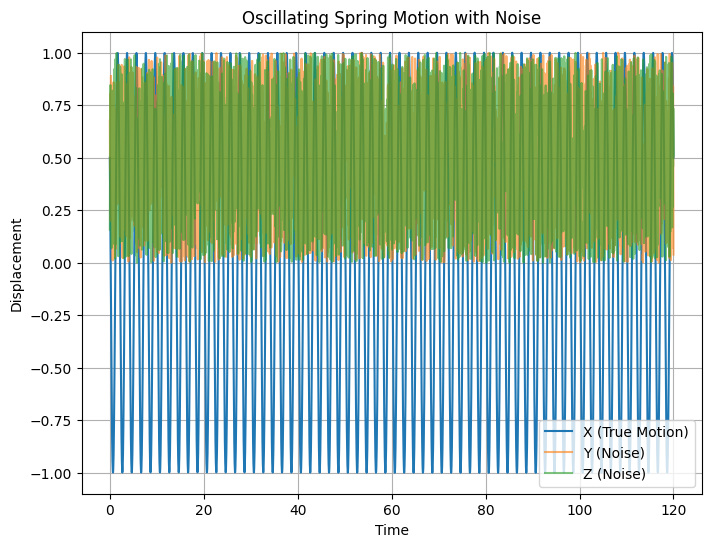

In [9]:
# Plot original dataset
plt.figure(figsize=(8, 6))
plt.plot(time, X[:, 0], label='X (True Motion)')
plt.plot(time, X[:, 1], label='Y (Noise)', alpha=0.6)
plt.plot(time, X[:, 2], label='Z (Noise)', alpha=0.6)
plt.xlabel("Time")
plt.ylabel("Displacement")
plt.title("Oscillating Spring Motion with Noise")
plt.legend()
plt.grid()
plt.show()

In [10]:
# camera angles
thetas = np.pi * npr.random(n)
phis = 2 * np.pi * npr.random(n)

# rotation matrices
R_theta = np.array([[ [1,0,0], [0,np.cos(t), - np.sin(t)], [0, np.sin(t), np.cos(t)] ] for t in thetas])
R_phi = np.array([[ [np.cos(p), - np.sin(p), 0], [np.sin(p), np.cos(p), 0], [0,0,1] ] for p in phis])
R = np.matmul(R_phi, R_theta)
print(R.shape)
print(f'Rotation Matrices of first two cameras:\n\n{R[:2, :, :]}')

(10, 3, 3)
Rotation Matrices of first two cameras:

[[[ 0.98610032  0.13019703 -0.10322251]
  [-0.166151    0.7727148  -0.61262197]
  [ 0.          0.62125725  0.78360668]]

 [[-0.25105257 -0.38258888 -0.88915598]
  [-0.96797345  0.09922785  0.23061056]
  [ 0.          0.91857476 -0.39524728]]]


In [11]:
# emulating cameras records
Recs = np.zeros(shape=(30,3000))                  #   
for cam in range(n):          #   for each camera apply its rotation matrix to the dataset
    r = np.dot(R[cam], X.T)   #   create records from each camera's perspective
    Recs[(cam*3):(cam*3+3), :] = r
#   dataset 10 measurements for each of 3 dimensions for 3000 rows 
print(f'Stacked records with shape:\n{Recs.shape}\nAnd head:\n     x_cam1      y_cam1      z_cam1\n{Recs[:3,:5].T}')

np.cov(Recs).shape

Stacked records with shape:
(30, 3000)
And head:
     x_cam1      y_cam1      z_cam1
[[ 0.56498454  0.34385252  0.54360887]
 [ 0.39188514 -0.0062527   0.64221713]
 [ 0.27180278 -0.00490094  1.07604656]
 [ 0.14040128 -0.04519335  1.06304164]
 [ 0.07027402  0.29203785  0.91968   ]]


(30, 30)

In [12]:
U, spectrum, Ut = la.svd(Recs @ Recs.T /(N-1))
print(f'Eigenvalues matrix and Eigenvectors shape:\n{U.shape, spectrum.shape}')
c = 2
print(
    f'The first {c + 1} components account for {np.sum(spectrum[:c]) * 100 / np.sum(spectrum):.2f}% of the dataset variability.'
)

Eigenvalues matrix and Eigenvectors shape:
((30, 30), (30,))
The first 3 components account for 93.06% of the dataset variability.


(3000, 30)


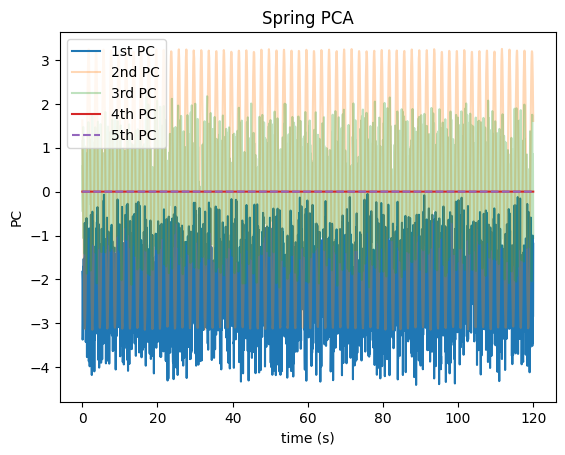

In [13]:
# change basis to the eigenvectors coordinate system
Recs_nb = np.real_if_close(np.matmul(Recs.T, U))
print(Recs_nb.shape)
# plot first principal component
fig, ax = plt.subplots()

ax.plot(time, Recs_nb[:,0], label = '1st PC')
ax.plot(time, Recs_nb[:,1], label = '2nd PC', alpha = 0.3)
ax.plot(time, Recs_nb[:,2], label = '3rd PC', alpha = 0.3)
ax.plot(time, Recs_nb[:,3], label = '4th PC')
ax.plot(time, Recs_nb[:,4], label = '5th PC', linestyle = 'dashed')
ax.legend()
ax.set_title('Spring PCA')
ax.set_xlabel('time (s)')
ax.set_ylabel('PC')
plt.show()

4\. **PCA on the MAGIC dataset** (optional)

Perform a PCA on the magic04.data dataset

In [14]:
# get the dataset and its description on the proper data directory
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data -P ~/data/
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.names -P ~/data/ 

--2025-02-06 11:50:48--  https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data
Risoluzione di archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connessione a archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connesso.
Richiesta HTTP inviata, in attesa di risposta... 200 OK
Lunghezza: non specificato
Salvataggio in: «/Users/Filippo/data/magic04.data.5»

magic04.data.5          [    <=>             ]   1,41M  1,42MB/s    in 1,0s    

2025-02-06 11:50:50 (1,42 MB/s) - «/Users/Filippo/data/magic04.data.5» salvato [1477391]

--2025-02-06 11:50:50--  https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.names
Risoluzione di archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connessione a archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connesso.
Richiesta HTTP inviata, in attesa di risposta... 200 OK
Lunghezza: non specificato
Salvataggio in: «/Users/Filippo/data/magic04.names.5»

magic04.names.5      

In [15]:
filename = "/Users/Filippo/data/magic04.data"
data = pd.read_csv(
    filename, 
    names=[
        'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class'
    ]
)
data.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  class     19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB


In [17]:
data['class'] = np.where(data['class'] == 'g', 1, 0)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  class     19020 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 1.6 MB


In [18]:
cov = data.cov()
cov.head(11)

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
fLength,1794.780934,598.863542,14.064229,-4.886995,-2.800380,-924.434103,-258.727155,11.814008,-9.706818,1324.864131,-6.221837
fWidth,598.863542,336.577782,6.221102,-2.045137,-1.178226,-289.972346,-164.893734,15.186087,31.636694,461.786200,-2.326648
fSize,14.064229,6.221102,0.223349,-0.073511,-0.042243,-4.473078,2.293535,0.152121,-2.302925,15.435467,-0.026582
fConc,-4.886995,-2.045137,-0.073511,0.033421,0.019726,1.215195,-1.136528,-0.043003,1.122738,-4.485661,0.002149
fConc1,-2.800380,-1.178226,-0.042243,0.019726,0.012213,0.655333,-0.669389,-0.025239,0.662907,-2.515795,0.000253
fAsym,-924.434103,-289.972346,-4.473078,1.215195,0.655333,3505.357776,827.482747,3.147931,-86.066350,-914.690722,4.907381
fM3Long,-258.727155,-164.893734,2.293535,-1.136528,-0.669389,827.482747,2601.012037,-18.266361,-247.985080,141.115155,4.709923
fM3Trans,11.814008,15.186087,0.152121,-0.043003,-0.025239,3.147931,-18.266361,433.782213,2.533034,17.785198,-0.038161
fAlpha,-9.706818,31.636694,-2.302925,1.122738,0.662907,-86.066350,-247.985080,2.533034,681.399004,-430.253247,-5.745768
fDist,1324.864131,461.786200,15.435467,-4.485661,-2.515795,-914.690722,141.115155,17.785198,-430.253247,5584.839983,-2.326678


[6.57979722e+03 3.85388229e+03 2.01638437e+03 1.32677392e+03
 6.10225863e+02 4.33599203e+02 1.17330701e+02 1.55844865e-01
 8.63156380e-02 1.05942519e-02 3.84503479e-04]


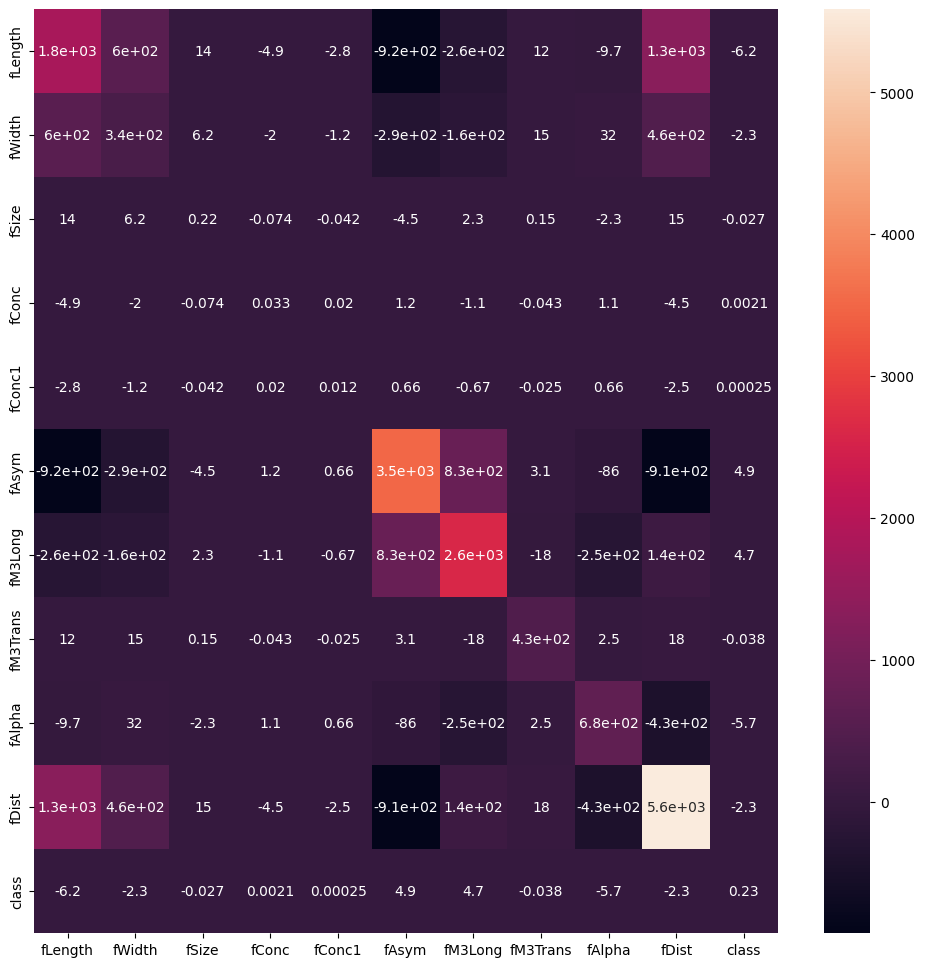

In [19]:
import seaborn as sns
plt.figure(figsize=(12, 12))
sns.heatmap(data=cov, fmt=".2g", annot=True)
plt.plot()

l, V = la.eig(cov)
l = np.real_if_close(l)
sorted_indices = np.argsort(l)[::-1]
l = l[sorted_indices]
V = V[:, sorted_indices]
print(l)

In [20]:
print(f"Contribution of first four components to total variability in the dataset: {np.sum(l[:4])/np.sum(l):.2f}%")

Contribution of first four components to total variability in the dataset: 0.92%


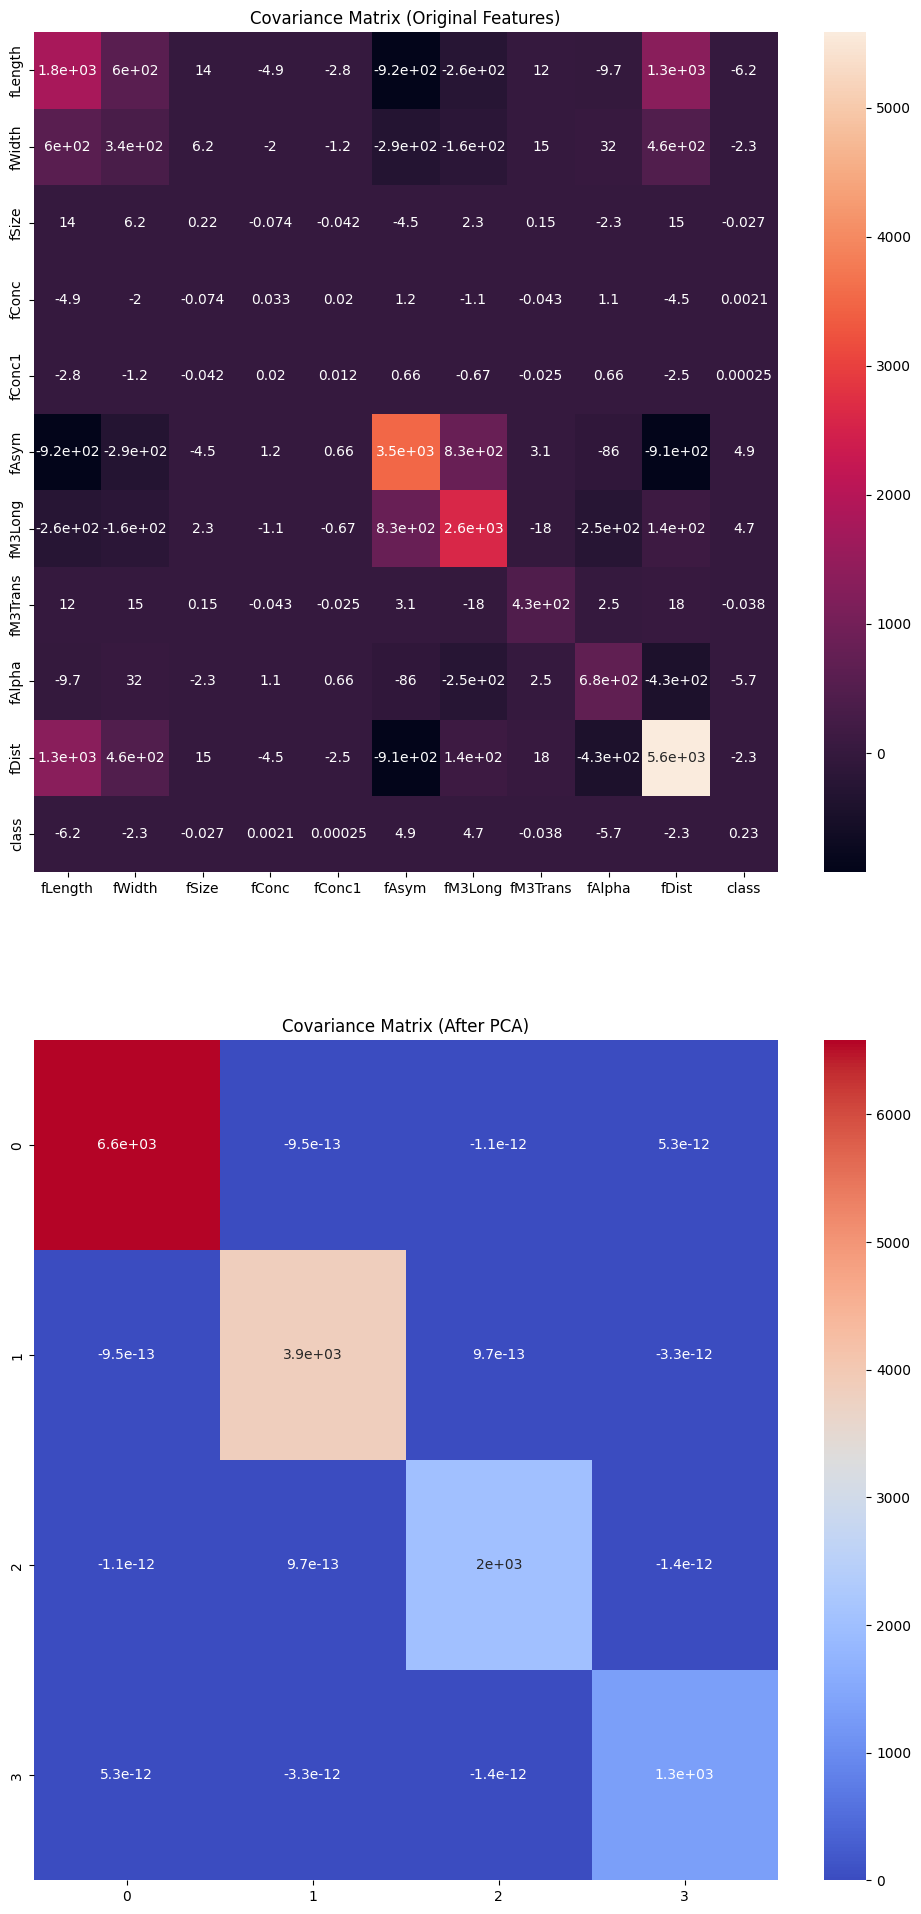

In [21]:
# Project onto first 4 principal components, 
# expect larger values for the variance-covariance matrix to be on the diagonal
data_pca = data @ V[:, :4]
cov_pca = np.cov(data_pca, rowvar=False)
plt.figure(figsize=(12,24))
plt.subplot(2, 1 ,1)
sns.heatmap(cov, annot=True, fmt=".2g")
plt.title("Covariance Matrix (Original Features)")

plt.subplot(2, 1, 2)
sns.heatmap(cov_pca, annot=True, fmt=".2g", cmap="coolwarm")
plt.title("Covariance Matrix (After PCA)")

plt.show()